# Fruit Detection - Local YOLOv11 Training

Recreated from the original Colab notebook, adapted to run fully on your local machine:
- No Google Drive mounting
- No Roboflow download (uses your local dataset already on disk)
- GPU training via CUDA (device=0)


## 1. Set project folder (HOME)

This replaces the Google Drive path. Everything (dataset, training runs, results) lives inside this folder.

In [3]:
import os

# Set this to your project's root folder on your computer
HOME = os.getcwd()  # or hardcode e.g. HOME = r"C:\Users\you\Projects\Fruit"
print(HOME)
os.chdir(HOME)

d:\Senior


## 2. Install dependencies

Run this once. If you've already installed these in your environment, you can skip this cell.

In [2]:
%pip install "ultralytics<=8.3.40" supervision

# prevent ultralytics from tracking your activity
!yolo settings sync=False

import ultralytics
ultralytics.checks()

Ultralytics 8.3.40  Python-3.11.0 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce RTX 2050, 4096MiB)
Setup complete  (12 CPUs, 27.7 GB RAM, 393.2/465.8 GB disk)


In [2]:
import torch
import torchvision
print("torch:", torch.__version__)
print("torchvision:", torchvision.__version__)
print("torchvision CUDA available:", torchvision.ops.nms)

torch: 2.5.1+cu121
torchvision: 0.20.1+cu121
torchvision CUDA available: <function nms at 0x0000022609C7E340>


In [3]:
print(torch.__version__)      # ควรลงท้าย +cu126
print(torchvision.__version__) # ควรลงท้าย +cu126 เช่นกัน

2.5.1+cu121
0.20.1+cu121


## 3. Point to your local dataset

Your dataset should already be organized like this inside `HOME/datasets/Fruits/`:

```
datasets/Fruits/
├── train/
│   ├── images/
│   └── labels/
├── valid/
│   ├── images/
│   └── labels/
├── test/            (optional)
│   ├── images/
│   └── labels/
└── data.yaml
```

Make sure `data.yaml` inside that folder correctly lists your `train`, `val`, `test` paths and your class `names`.

In [4]:
DATA_YAML = f"{HOME}/dataset/data.yaml"

assert os.path.exists(DATA_YAML), f"data.yaml not found at {DATA_YAML} - check your dataset path"
print("Using dataset config:", DATA_YAML)

Using dataset config: d:\Senior/dataset/data.yaml


In [5]:
import os
print(os.path.exists("D:/Senior/dataset/valid/images"))
print(os.listdir("D:/Senior/dataset"))

True
['data.yaml', 'test', 'train', 'valid']


In [8]:
import numpy
print(numpy.__version__)  # should show 1.x now
print(hasattr(numpy, "trapz"))  # should be True

1.26.4
True


## 4. Train the model

Trains YOLOv11s on your local dataset. `device=0` uses your first CUDA GPU.

In [9]:
from ultralytics import YOLO
model = YOLO("yolo11s.pt")

results = model.train(
    data=DATA_YAML,
    epochs=50,
    patience=15,
    imgsz=640,
    device=0,
    batch=8,        # เริ่มที่ 8 ก่อน ถ้าไม่ error ค่อยลองขยับเป็น 16
    workers=4,       # CPU cores ปกติมีจำกัด ไม่ต้องตั้งสูงเกินไป
    cache="ram",
    plots=True,
)

New https://pypi.org/project/ultralytics/8.4.130 available  Update with 'pip install -U ultralytics'
Ultralytics 8.3.40  Python-3.11.0 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce RTX 2050, 4096MiB)
engine\trainer: task=detect, mode=train, model=yolo11s.pt, data=d:\Senior/dataset/data.yaml, epochs=50, time=None, patience=15, batch=8, imgsz=640, save=True, save_period=-1, cache=ram, device=0, workers=4, project=None, name=train4, exist_ok=False, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nms=False, classes=None, retina_masks=False, embed=None, show=False, save_

train: Scanning D:\Senior\dataset\train\labels.cache... 16005 images, 0 backgrounds, 0 corrupt: 100%|██████████| 16005/16005 [00:00<?, ?it/s]


train: 22.9GB RAM required to cache images with 50% safety margin but only 13.9/27.7GB available, not caching images 


val: Scanning D:\Senior\dataset\valid\labels.cache... 4573 images, 0 backgrounds, 0 corrupt: 100%|██████████| 4573/4573 [00:00<?, ?it/s]

WARNING  cache='ram' may produce non-deterministic training results. Consider cache='disk' as a deterministic alternative if your disk space allows.


...

      50/50      2.48G    0.02046    0.03454     0.8617          5        640: 100%|██████████| 2001/2001 [09:56<00:00,  3.35it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 286/286 [01:41<00:00,  2.83it/s]

                   all       4573       4573      0.997      0.999      0.995      0.995



50 epochs completed in 10.213 hours.
Optimizer stripped from runs\detect\train4\weights\last.pt, 19.2MB
Optimizer stripped from runs\detect\train4\weights\best.pt, 19.2MB

Validating runs\detect\train4\weights\best.pt...
Ultralytics 8.3.40  Python-3.11.0 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce RTX 2050, 4096MiB)
YOLO11s summary (fused): 238 layers, 9,457,692 parameters, 0 gradients, 21.5 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 286/286 [00:56<00:00,  5.08it/s]


                   all       4573       4573      0.997      0.999      0.995      0.995
         Advil Tablets         14         14      0.928          1      0.995      0.995
          Alcohol Pads         47         47      0.998          1      0.995      0.995
              Aleve PM         40         40      0.998          1      0.995      0.995
         Aleve Tablets         43         43      0.998          1      0.995      0.995
All Free and Clear Pods         51         51      0.998          1      0.995      0.995
Arm and Hammer Toothpaste         40         40      0.998          1      0.995      0.995
       Bandaid Variety         39         39      0.998          1      0.995      0.995
                 Banza         55         55      0.999      0.982       0.99       0.99
         Barilla Penne         51         51      0.998          1      0.995      0.995
    Barilla Red Lentil         45         45      0.998          1      0.995      0.995
  Barilla Rotini 

## 5. Check training output folder

Ultralytics saves results under `HOME/runs/detect/train` (or `train2`, `train3`, ... if you've trained before).

In [10]:
!ls "{HOME}/runs/detect/train" 

'ls' is not recognized as an internal or external command,
operable program or batch file.


## 6. View results

Adjust the folder name below (`train`, `train2`, etc.) to match whatever Ultralytics created above.

In [12]:
from IPython.display import Image as IPyImage

RUN_DIR = f"{HOME}/runs/detect/train4"  # update if it's train2, train3, etc.

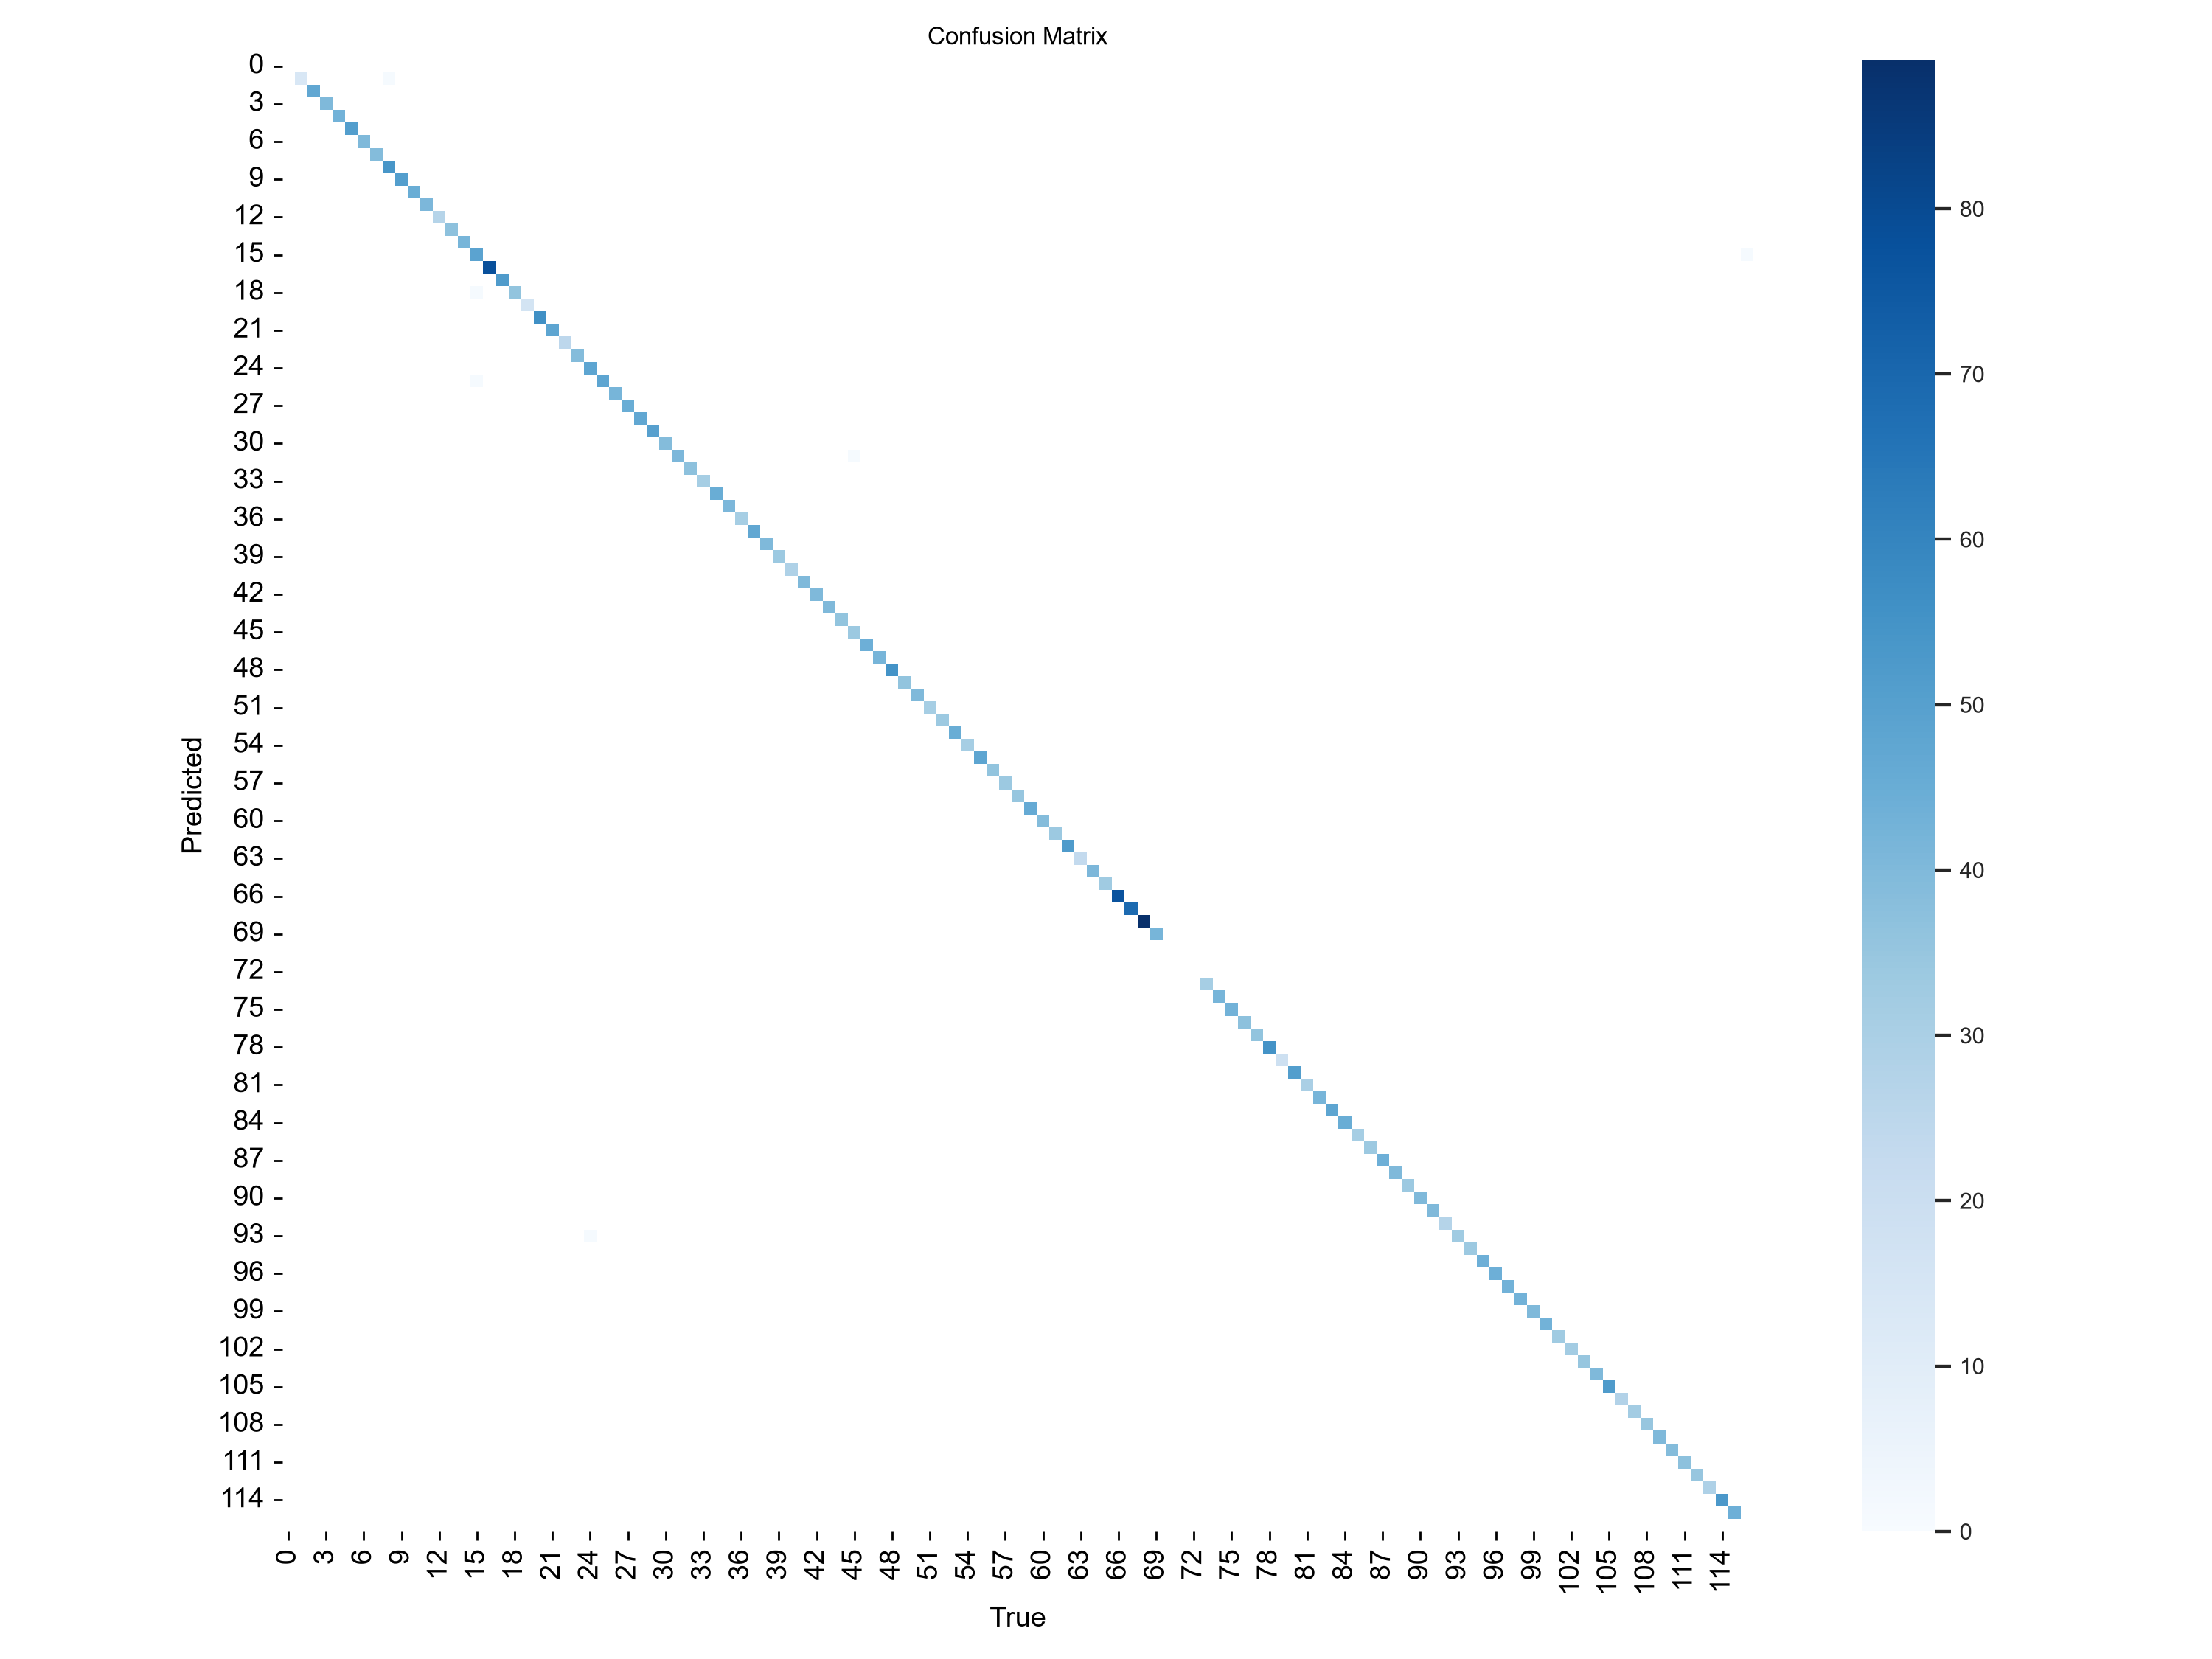

In [13]:
IPyImage(filename=f"{RUN_DIR}/confusion_matrix.png", width=600)

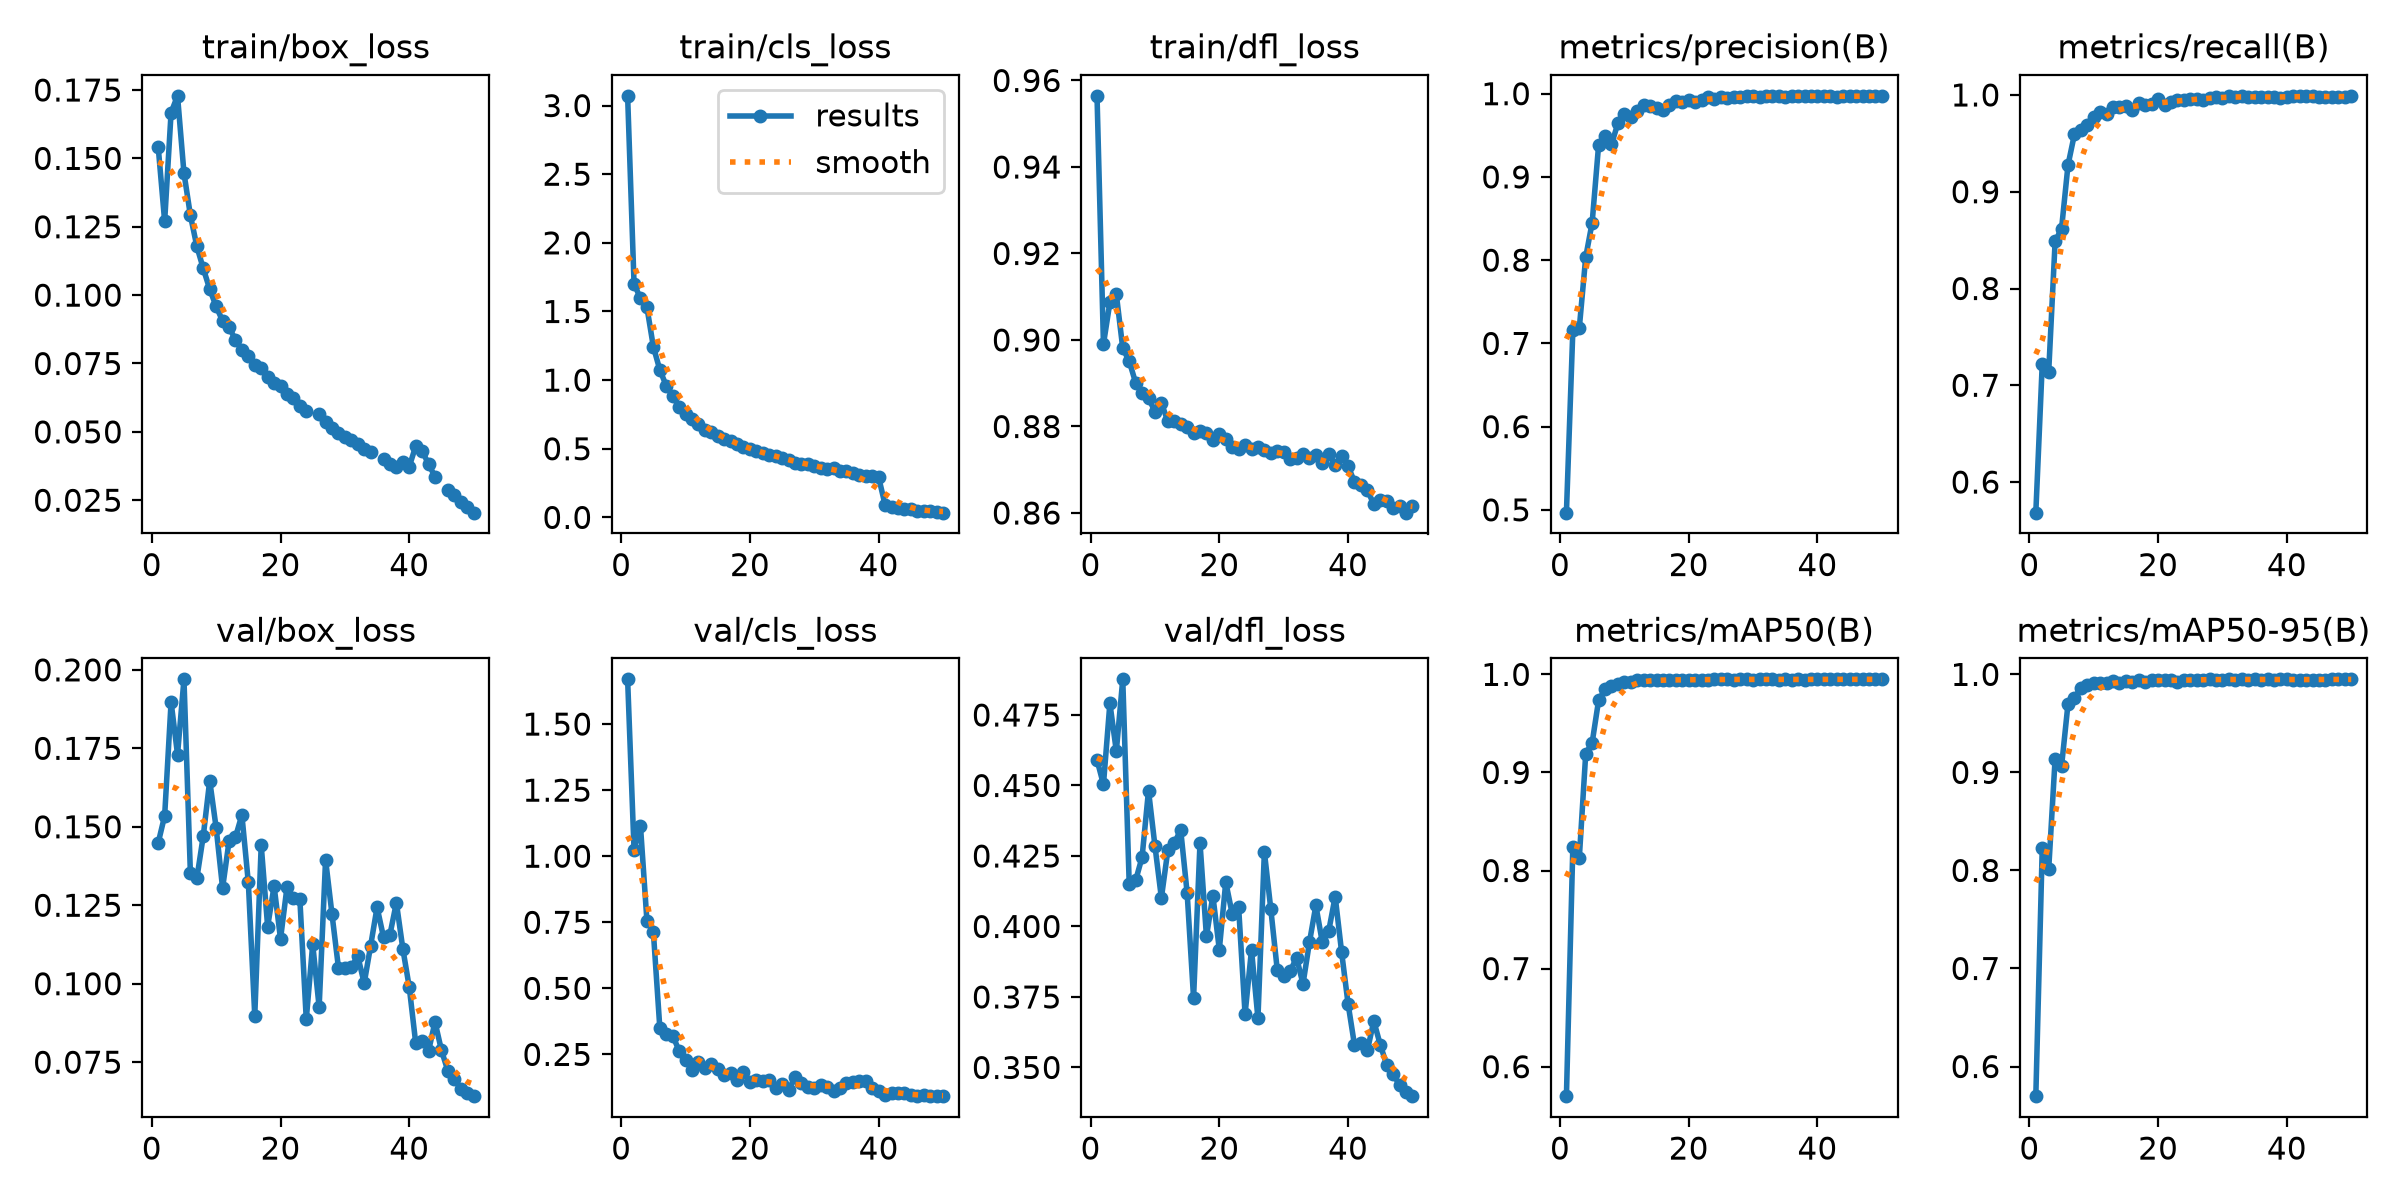

In [14]:
IPyImage(filename=f"{RUN_DIR}/results.png", width=600)

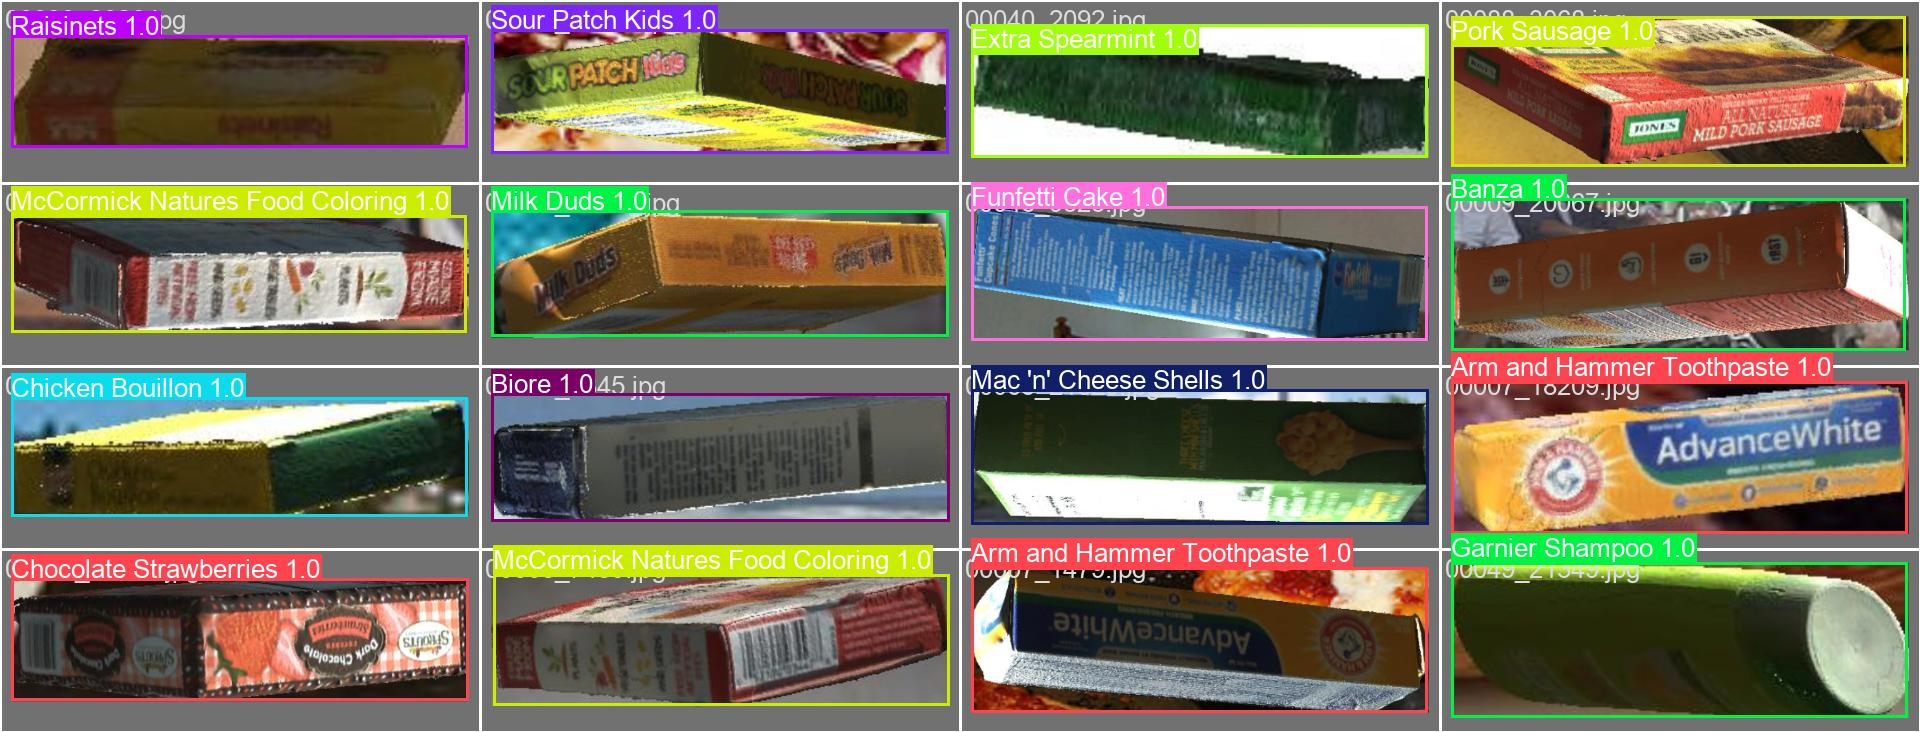

In [15]:
IPyImage(filename=f"{RUN_DIR}/val_batch0_pred.jpg", width=600)

In [25]:
results = model.predict(
    source=f"{HOME}/testA/testA_3.mp4",
    save=True,
    imgsz=640,       # lower if your video is high-res
    stream=True,      # processes frame-by-frame instead of loading all at once
    device='cpu'       # or 'cuda' if you have a working GPU — try switching to see if it's GPU vs CPU memory
)

In [26]:
model = YOLO(f"{HOME}/runs/detect/train4/weights/best.pt")
results = model.predict(
    source=f"{HOME}/testA/testA_3.mp4",
    save=True
)



WARNING  inference results will accumulate in RAM unless `stream=True` is passed, causing potential out-of-memory
errors for large sources or long-running streams and videos. See https://docs.ultralytics.com/modes/predict/ for help.

Example:
    results = model(source=..., stream=True)  # generator of Results objects
    for r in results:
        boxes = r.boxes  # Boxes object for bbox outputs
        masks = r.masks  # Masks object for segment masks outputs
        probs = r.probs  # Class probabilities for classification outputs

video 1/1 (frame 1/19831) d:\Senior\testA\testA_3.mp4: 384x640 (no detections), 17.9ms
video 1/1 (frame 2/19831) d:\Senior\testA\testA_3.mp4: 384x640 (no detections), 19.8ms
video 1/1 (frame 3/19831) d:\Senior\testA\testA_3.mp4: 384x640 (no detections), 24.2ms
video 1/1 (frame 4/19831) d:\Senior\testA\testA_3.mp4: 384x640 (no detections), 22.9ms
video 1/1 (frame 5/19831) d:\Senior\testA\testA_3.mp4: 384x640 (no detections), 16.6ms
video 1/1 (frame 6/1983

MemoryError: Unable to allocate 5.93 MiB for an array with shape (1080, 1920, 3) and data type uint8

In [27]:
import cv2

input_path = r"D:\Senior\runs\detect\predict4\testA_3.avi"
output_path = r"D:\Senior\runs\detect\predict4\detected_video.mp4"

cap = cv2.VideoCapture(input_path)
fps = cap.get(cv2.CAP_PROP_FPS)
width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

fourcc = cv2.VideoWriter_fourcc(*'mp4v')
out = cv2.VideoWriter(output_path, fourcc, fps, (width, height))

while True:
    ret, frame = cap.read()
    if not ret:
        break
    out.write(frame)

cap.release()
out.release()
print("Done:", output_path)

KeyboardInterrupt: 